**ANE-S BDD-30k GT supervised baseline**

In [1]:
import os
from google.colab import drive, userdata
import json
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Image

drive.mount("/content/drive")
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

Mounted at /content/drive


In [2]:
!pip install -q uv
!uv --version

%cd /content

!rm -rf /content/adp
!git clone --branch v2-research-framework https://github.com/aekn/ane-drive-perc.git adp

%cd /content/adp

!uv sync
!uv run python -m compileall -q src

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 98.5 MB/s eta 0:00:00
uv 0.11.11 (x86_64-unknown-linux-gnu)
/content
Cloning into 'adp'...
remote: Enumerating objects: 452, done.
remote: Counting objects: 100% (452/452), done.
remote: Compressing objects: 100% (284/284), done.
remote: Total 452 (delta 155), reused 417 (delta 120), pack-reused 0 (from 0)
Receiving objects: 100% (452/452), 429.97 KiB | 4.39 MiB/s, done.
Resolving deltas: 100% (155/155), done.
/content/adp
Using CPython 3.12.13 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
Resolved 76 packages in 0.87ms
⠙ Preparing packages... (0/74)                                                  warning: `build_system.requires = ["uv-build>=0.9.21,<0.10.0"]` does not contain the current uv version 0.11.11
Prepared 74 packages in 34.13s
Installed 74 packages in 247ms
 + adp==0.1.0 (from file:///content/adp)
 + albucore==0.0.24
 + albumentations==2.0.8
 + annotated-doc==0.0.4
 + annotated-types==0.7.0
 

In [3]:
%cd /content/adp

# stage bdd30k from hf
!uv run python -u -m adp.data.stage \
  experiment.name=stage_bdd_det10_train30k_s42 \
  data.package_name=bdd_det10_train30k_s42 \
  hf.files.train_package=packages/bdd_det10_train30k_s42.tar \
  hf.files.train_checksum=checksums/bdd_det10_train30k_s42.sha256 \
  hf.files.val_package=packages/bdd_det10_val.tar \
  hf.files.val_checksum=checksums/bdd_det10_val.sha256 \
  stage.output_dir=/content/adp/data/staged/bdd_det10_train30k_s42 \
  stage.download_dir=/content/adp/data/downloads/hf/bdd_det10_train30k_s42

# validate stage
!uv run python -u -m adp.data.validate \
  experiment.name=validate_staged_bdd_det10_train30k_s42 \
  data.root=/content/adp/data/staged/bdd_det10_train30k_s42

# export2coco
!uv run python -u -m adp.data.export_coco \
  data.package_name=bdd_det10_train30k_s42 \
  data.root=/content/adp/data/staged/bdd_det10_train30k_s42 \
  export.root=/content/adp/data/exports/bdd_det10_train30k_s42

/content/adp
[adp] downloading train package
[2026-05-07 17:18:20,814][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/datasets/aekn/adp-bdd/resolve/main/packages/bdd_det10_train30k_s42.tar "HTTP/1.1 302 Found"
[2026-05-07 17:18:20,871][httpx][INFO] - HTTP Request: GET https://huggingface.co/api/datasets/aekn/adp-bdd/xet-read-token/c63f78d214334af30ef5a8172a6932c56acd773b "HTTP/1.1 200 OK"
packages/bdd_det10_train30k_s42.tar: 100% 1.91G/1.91G [00:06<00:00, 307MB/s]
[2026-05-07 17:18:27,184][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/datasets/aekn/adp-bdd/resolve/main/checksums/bdd_det10_train30k_s42.sha256 "HTTP/1.1 200 OK"
[2026-05-07 17:18:27,260][httpx][INFO] - HTTP Request: GET https://huggingface.co/datasets/aekn/adp-bdd/resolve/main/checksums/bdd_det10_train30k_s42.sha256 "HTTP/1.1 200 OK"
bdd_det10_train30k_s42.sha256: 100% 93.0/93.0 [00:00<00:00, 407kB/s]
[adp] downloading val package
[2026-05-07 17:18:32,785][httpx][INFO] - HTTP Request: HEAD https://hug

In [ ]:
%cd /content/adp

# ideally we would train for 120 epochs
# seems to be nowhere near converging

!uv run python -u -m adp.train.train \
  +experiment=ane_s_bdd_finetune \
  experiment.name=ane_s_bdd30k_544x960_a100_bs32_e65 \
  paths.runs=/content/drive/MyDrive/projects/ane-drive-perc/runs/ane \
  train.coco_root=/content/adp/data/exports/bdd_det10_train30k_s42/coco \
  train.batch_size=24 \
  train.num_workers=8 \
  train.base_lr=0.0002 \
  train.backbone_lr=0.00002 \
  train.epochs=40 \
  train.amp_dtype=bfloat16 \
  train.device=cuda

/content/adp
2026-05-07 06:22:44.624 | INFO     | __main__:main:128 - device: cuda
2026-05-07 06:22:44.624 | INFO     | __main__:main:129 - amp dtype: torch.bfloat16
2026-05-07 06:22:44.624 | INFO     | __main__:main:130 - image size: (544, 960)
2026-05-07 06:22:44.625 | INFO     | __main__:main:141 - model: ane_s  (family=ane size=s)
[2026-05-07 06:22:45,618][timm.models._builder][INFO] - Loading pretrained weights from Hugging Face hub (timm/fastvit_t8.apple_in1k)
[2026-05-07 06:22:45,778][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/timm/fastvit_t8.apple_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
[2026-05-07 06:22:45,829][httpx][INFO] - HTTP Request: GET https://huggingface.co/api/models/timm/fastvit_t8.apple_in1k/xet-read-token/cbc6c66a249060c66b8236284c7c3998e900e944 "HTTP/1.1 200 OK"
model.safetensors: 100% 16.3M/16.3M [00:01<00:00, 15.9MB/s]
[2026-05-07 06:22:46,852][timm.models._hub][INFO] - [timm/fastvit_t8.apple_in1k] Safe alternative available for '

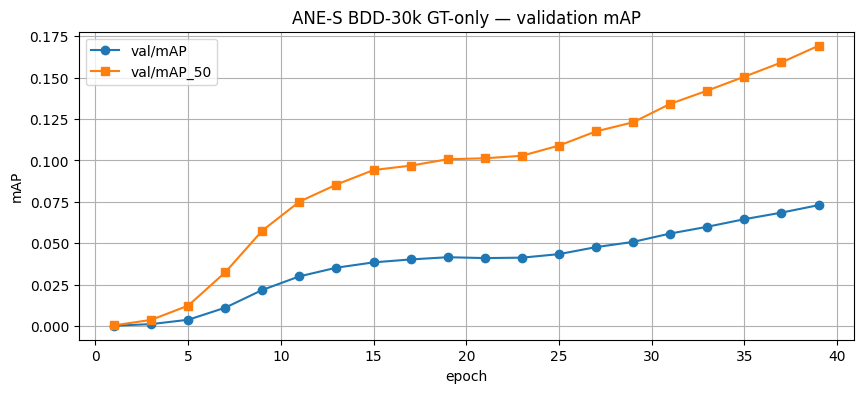

best val/mAP    = 0.0730 at epoch 39
best val/mAP_50 = 0.1693 at epoch 39


In [4]:
RUN_DIR = "/content/drive/MyDrive/projects/ane-drive-perc/runs/ane/ane_s_bdd30k_544x960_a100_bs32_e65"

with open(f"{RUN_DIR}/metrics.jsonl") as f:
    rows = [json.loads(line) for line in f if line.strip()]

ep = [r["epoch"] for r in rows if "val/mAP" in r]
mAP = [r["val/mAP"] for r in rows if "val/mAP" in r]
mAP5 = [r["val/mAP_50"] for r in rows if "val/mAP_50" in r]

plt.figure(figsize=(10, 4))
plt.plot(ep, mAP, label="val/mAP", marker="o")
plt.plot(ep, mAP5, label="val/mAP_50", marker="s")
plt.xlabel("epoch")
plt.ylabel("mAP")
plt.legend()
plt.grid(True)
plt.title("ANE-S BDD-30k GT-only — validation mAP")
plt.show()

if mAP:
    best_i = mAP.index(max(mAP))
    best50_i = mAP5.index(max(mAP5))
    print(f"best val/mAP    = {max(mAP):.4f} at epoch {ep[best_i]}")
    print(f"best val/mAP_50 = {max(mAP5):.4f} at epoch {ep[best50_i]}")

In [5]:
%cd /content/adp

!uv run python -u -m adp.eval.visualize_predictions \
  +experiment=ane_s_bdd_finetune \
  experiment.name=ane_s_bdd30k_544x960_a100_bs32_e65 \
  paths.runs=/content/drive/MyDrive/projects/ane-drive-perc/runs/ane \
  train.coco_root=/content/adp/data/exports/bdd_det10_train30k_s42/coco \
  eval.checkpoint_path=/content/drive/MyDrive/projects/ane-drive-perc/runs/ane/ane_s_bdd30k_544x960_a100_bs32_e65/checkpoints/best.pt \
  eval.score_threshold=0.3 \
  eval.max_images=24 \
  eval.nms_iou_threshold=0.6 \
  train.device=cuda

/content/adp
[adp] wrote 24 prediction visualizations: /content/drive/MyDrive/projects/ane-drive-perc/runs/ane/ane_s_bdd30k_544x960_a100_bs32_e65/debug/predictions
[adp] wrote report: /content/drive/MyDrive/projects/ane-drive-perc/runs/ane/ane_s_bdd30k_544x960_a100_bs32_e65/debug/prediction_visualization.json
[adp] ground truth = green
[adp] predictions = class colors shown in legend
[adp] visualization NMS IoU: 0.60
[adp] class-agnostic NMS: False


24 images at /content/drive/MyDrive/projects/ane-drive-perc/runs/ane/ane_s_bdd30k_544x960_a100_bs32_e65/debug/predictions


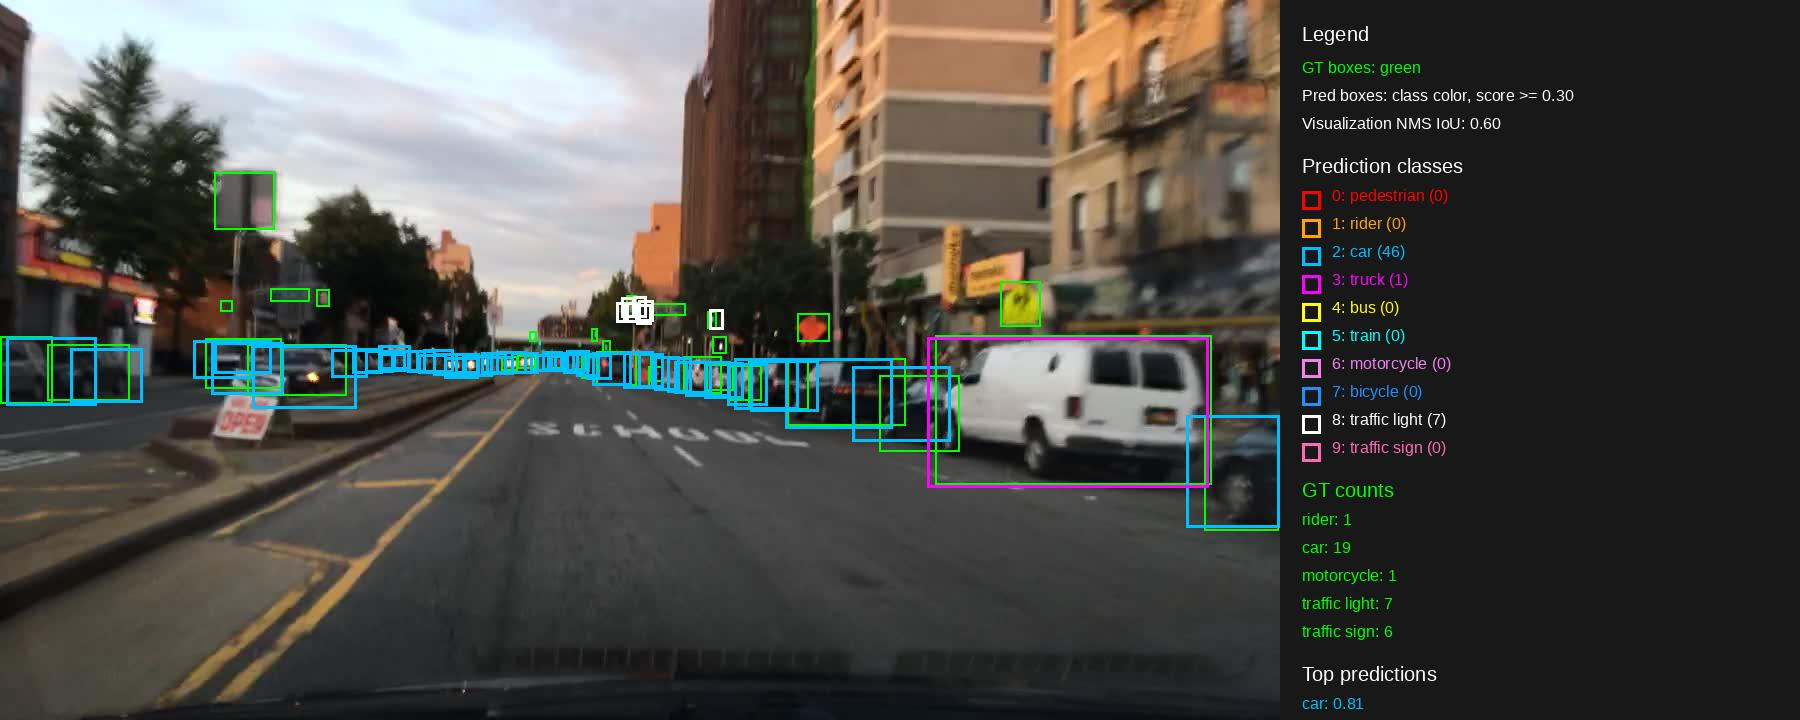

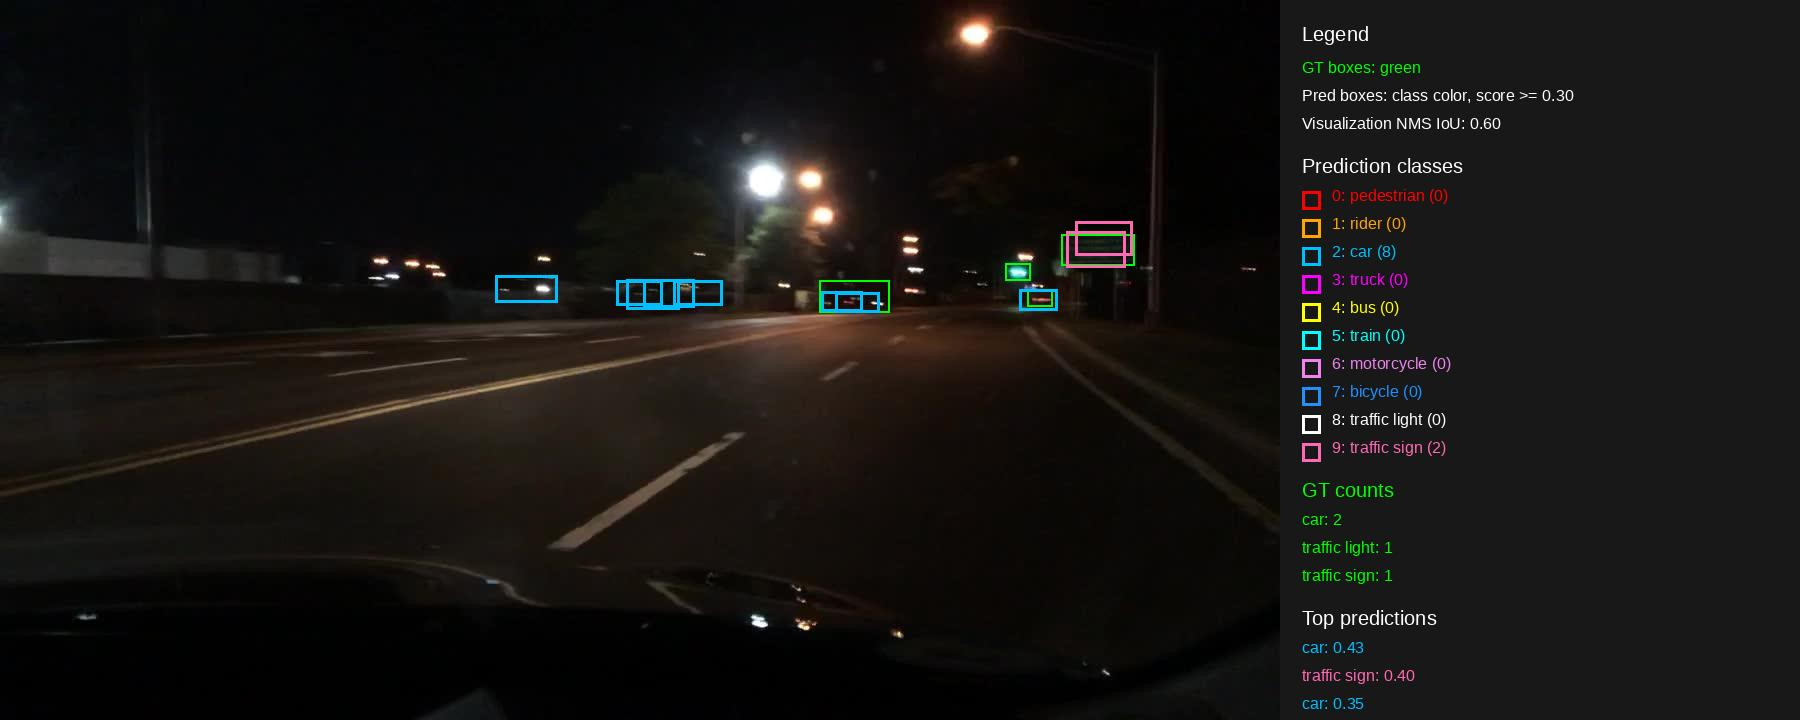

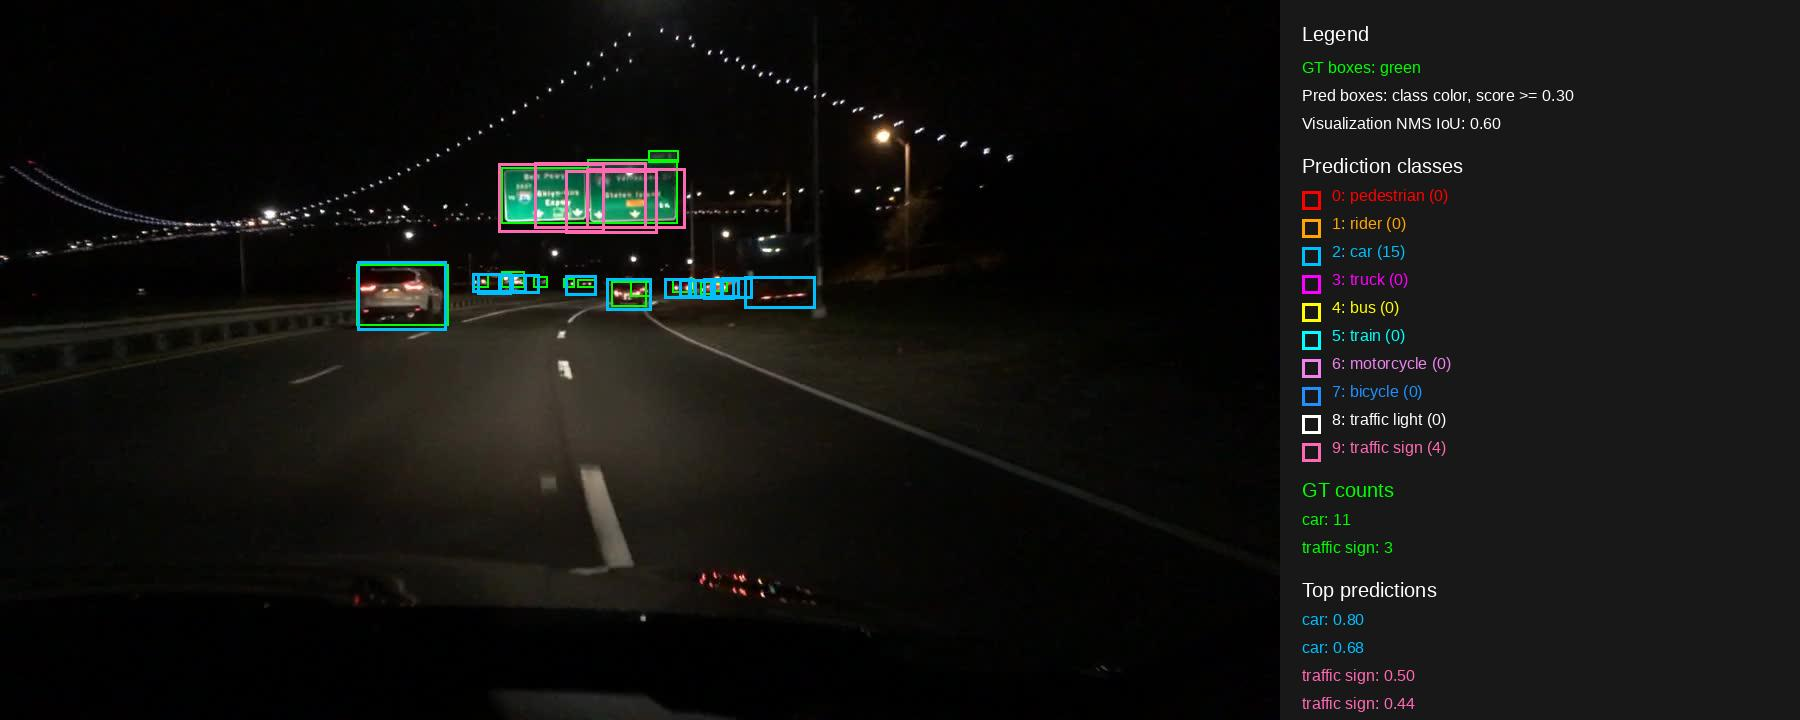

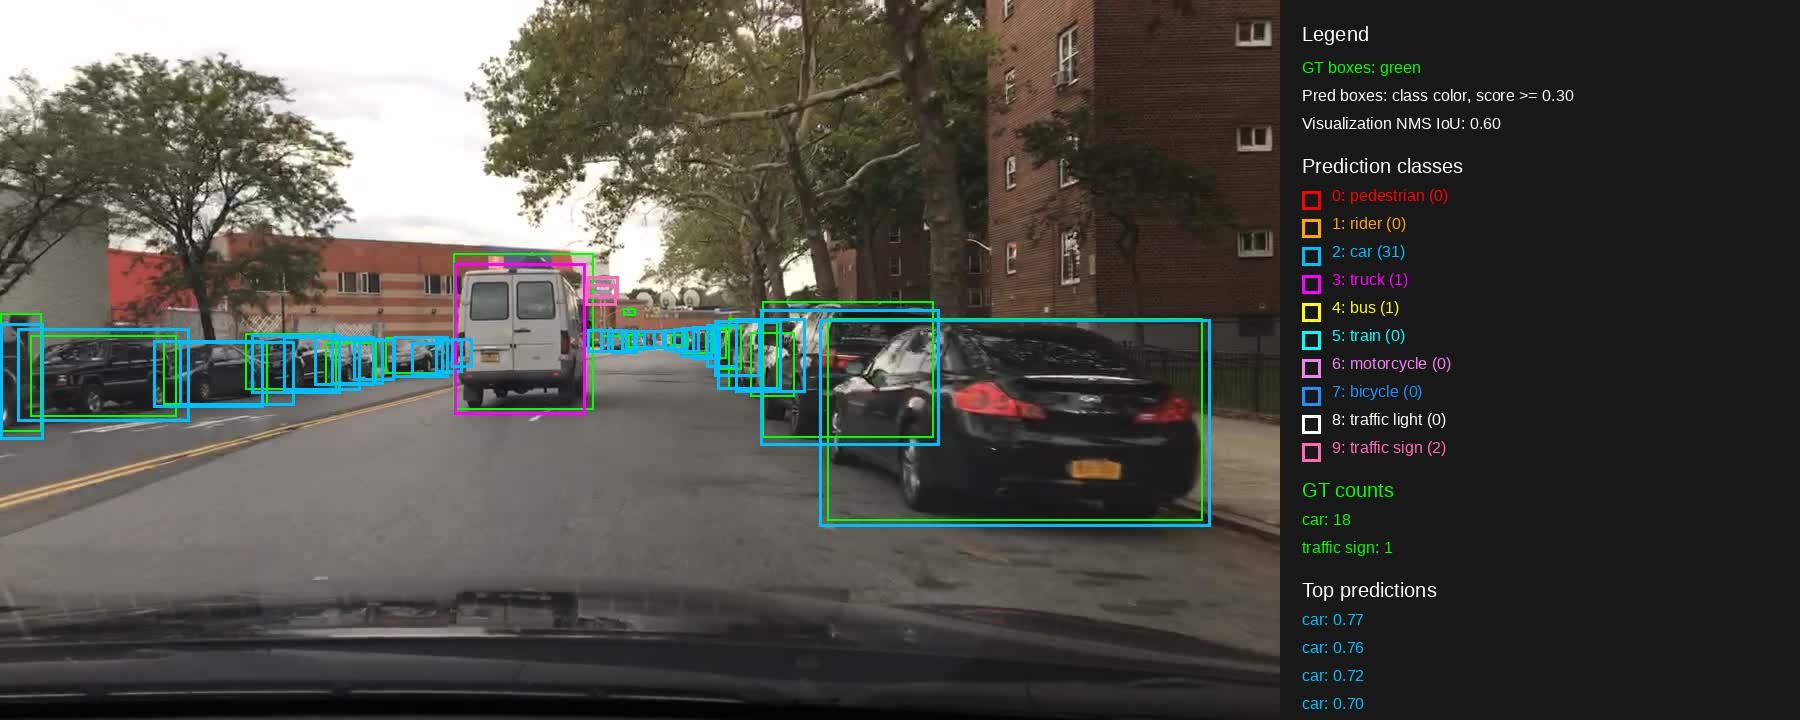

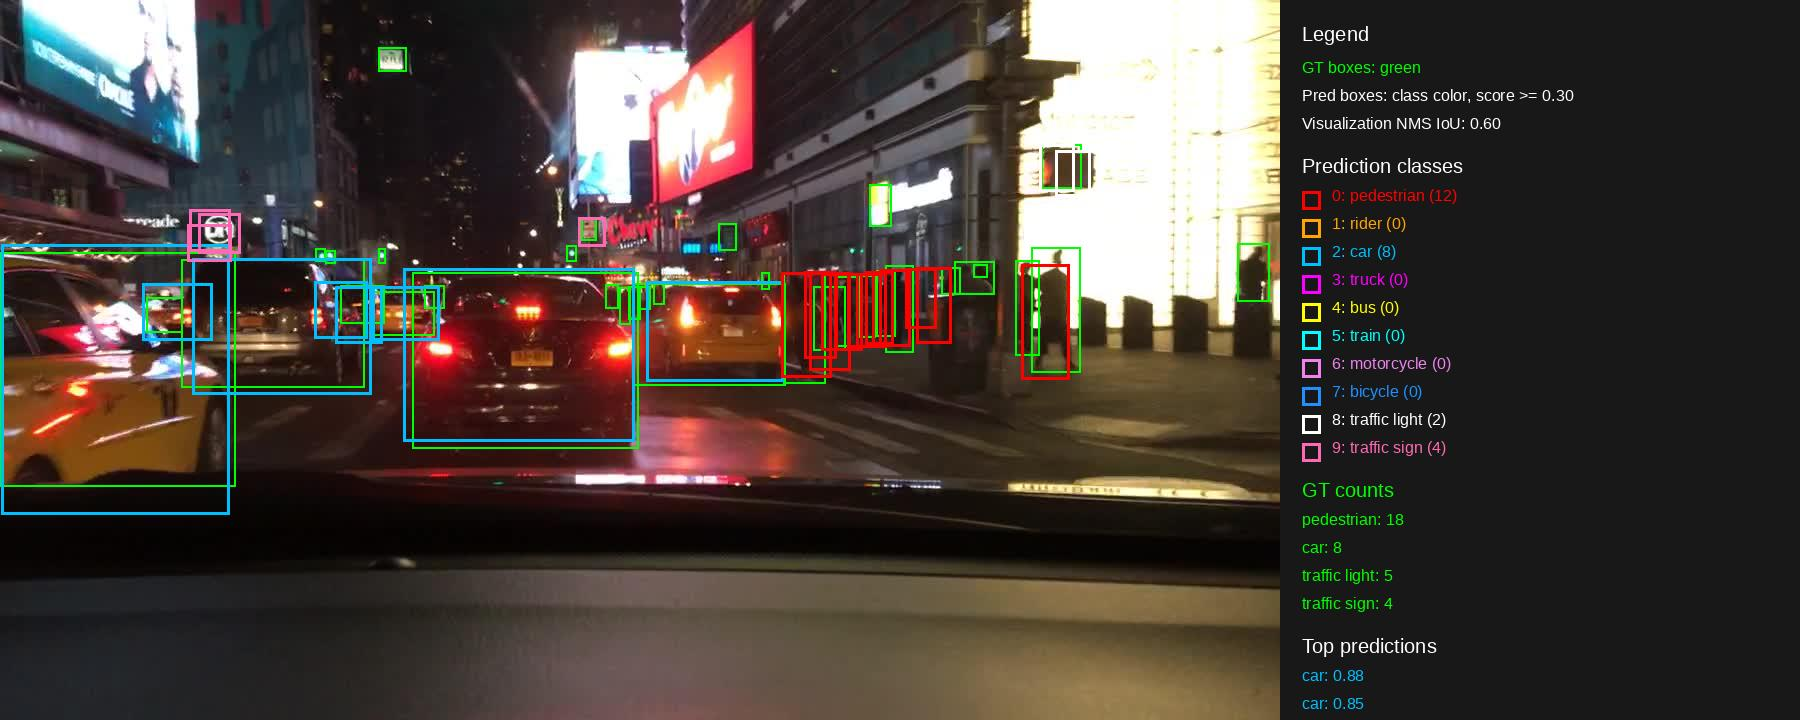

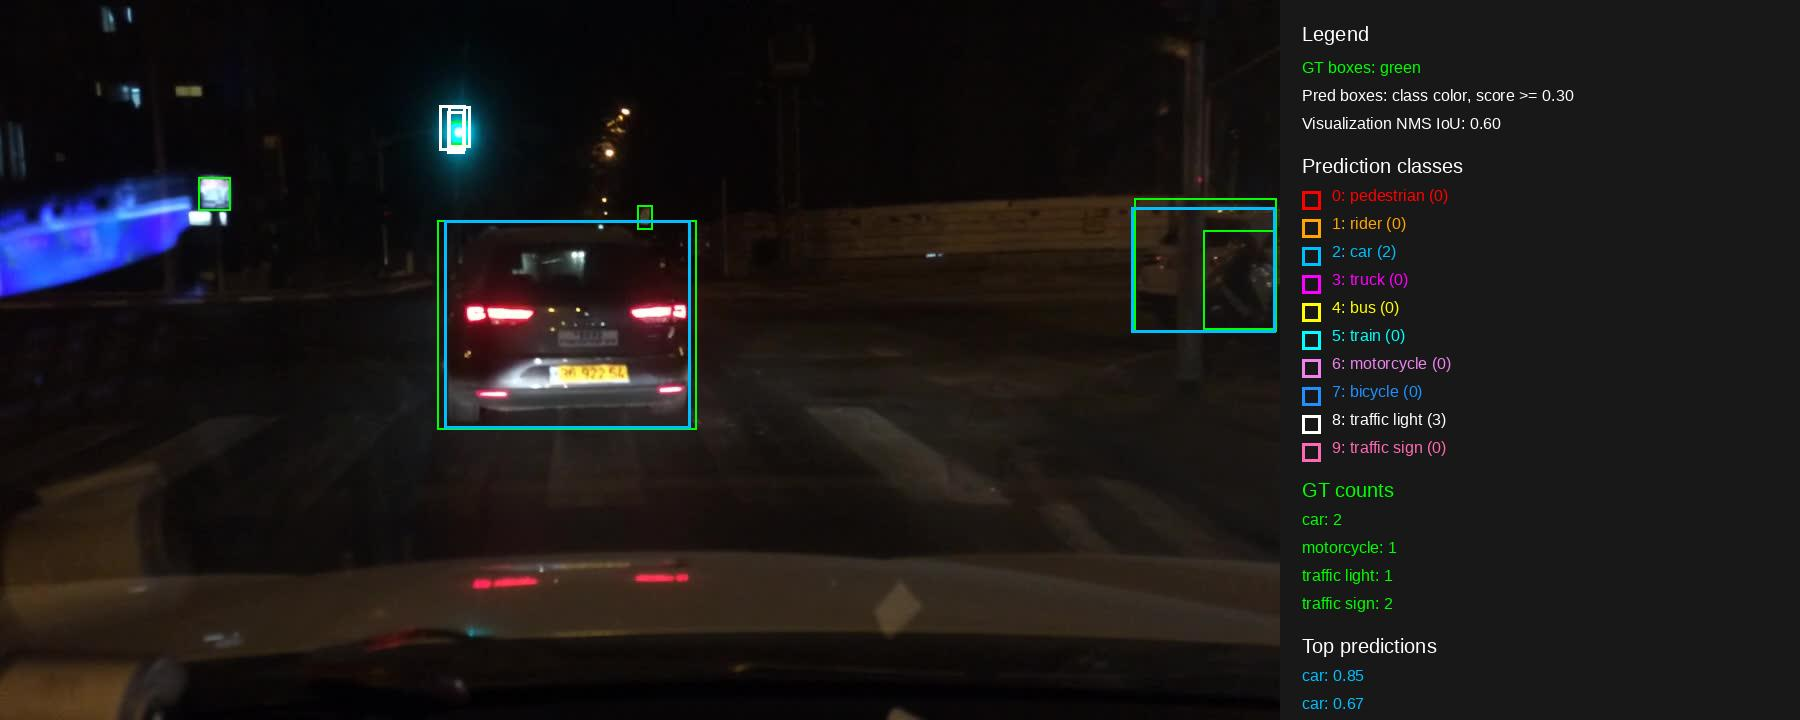

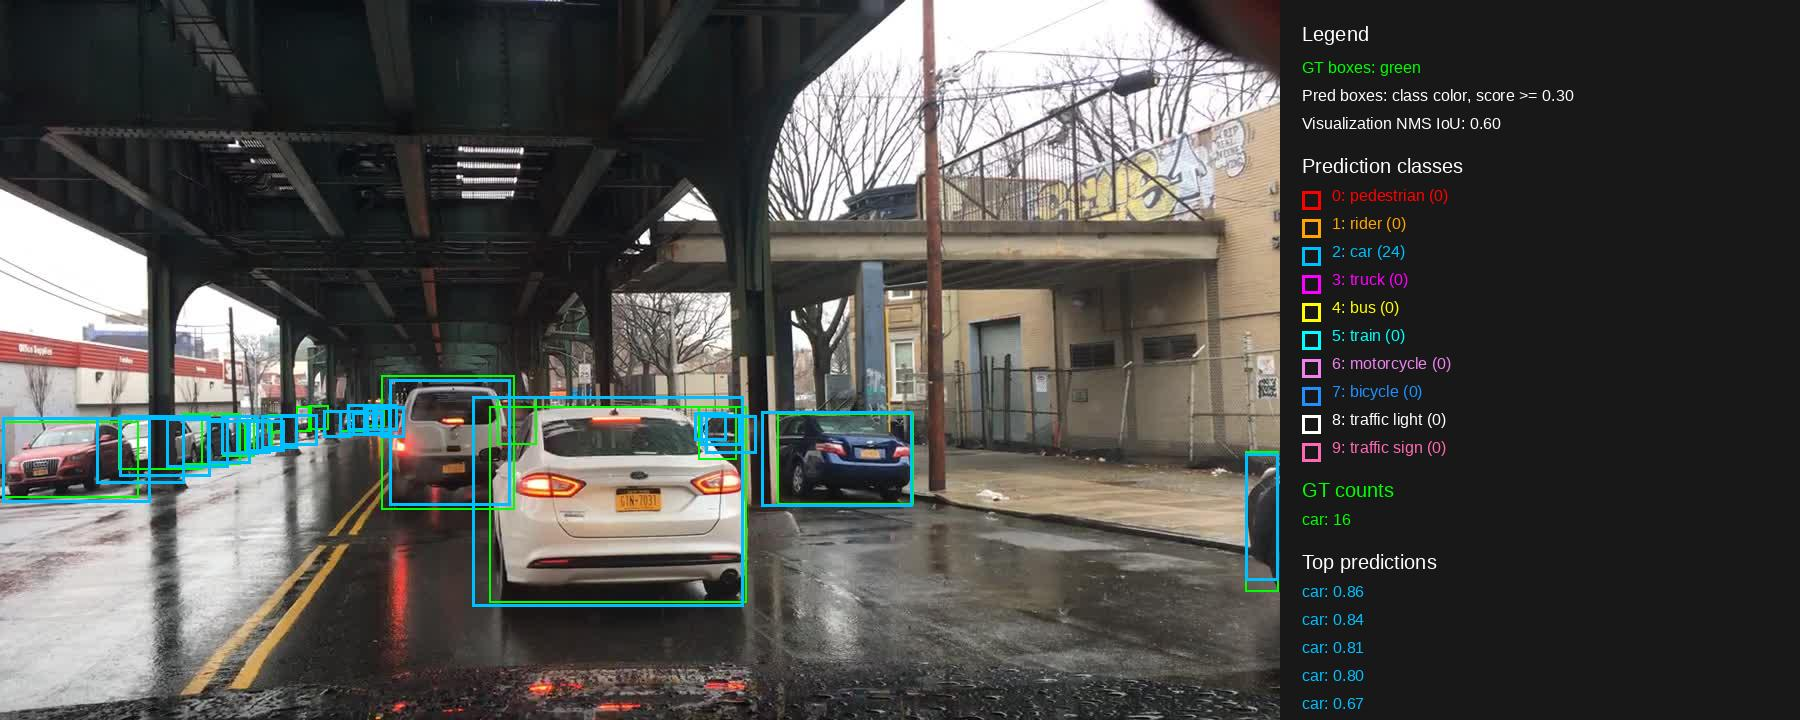

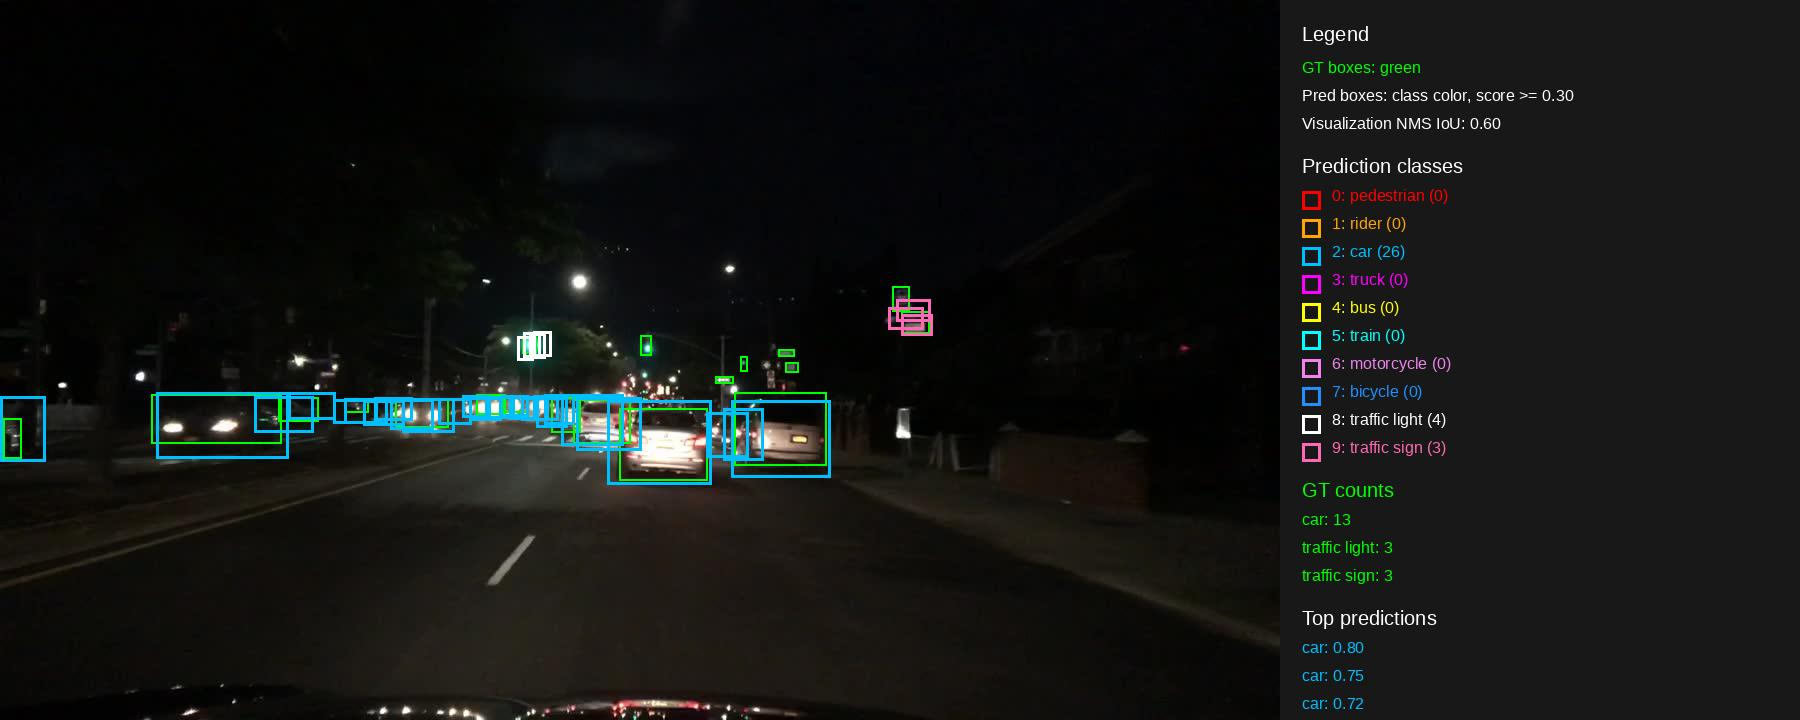

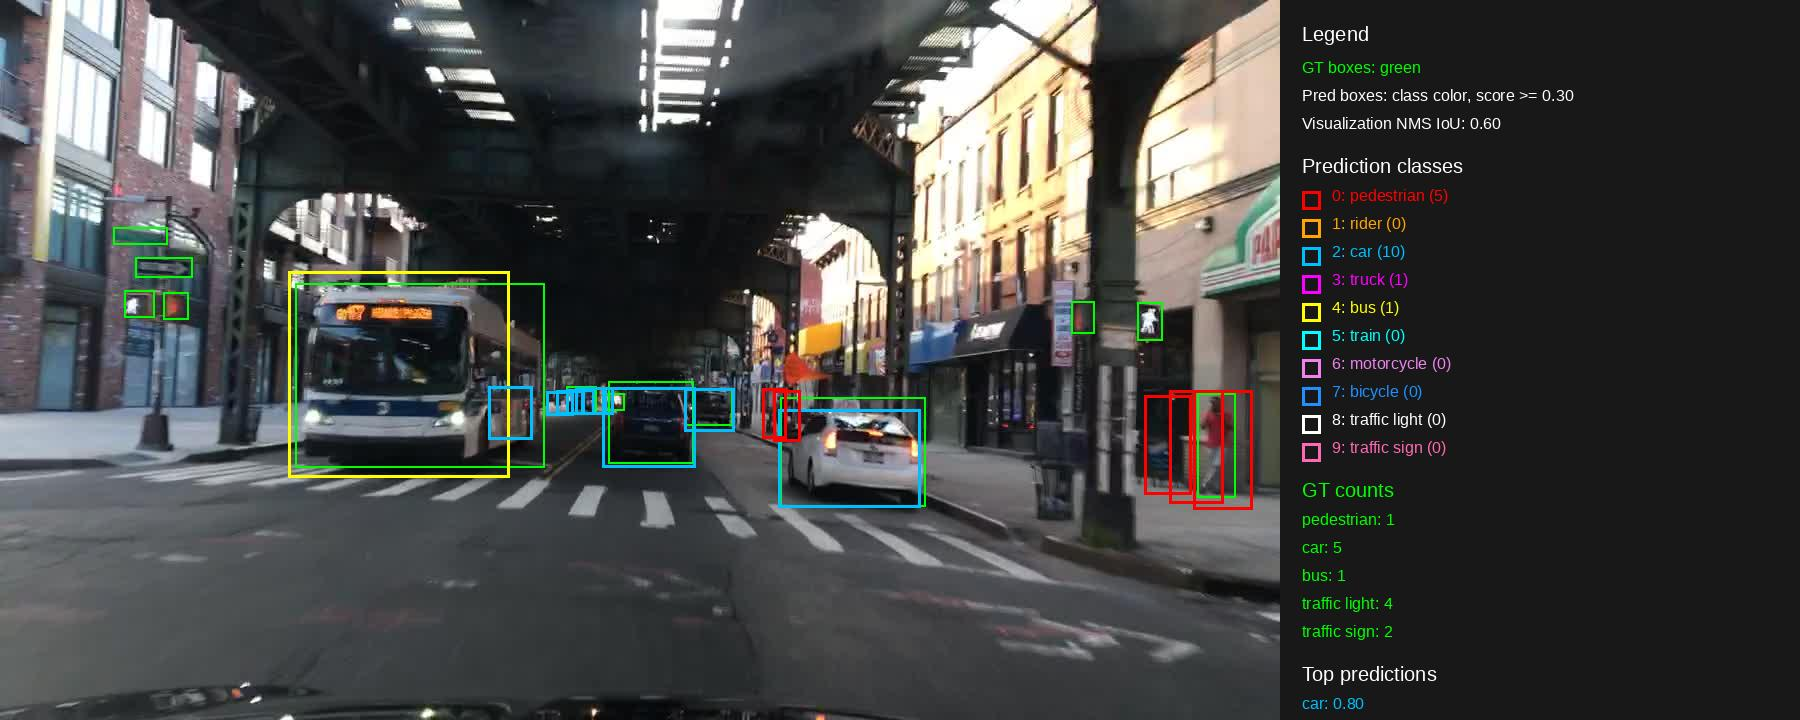

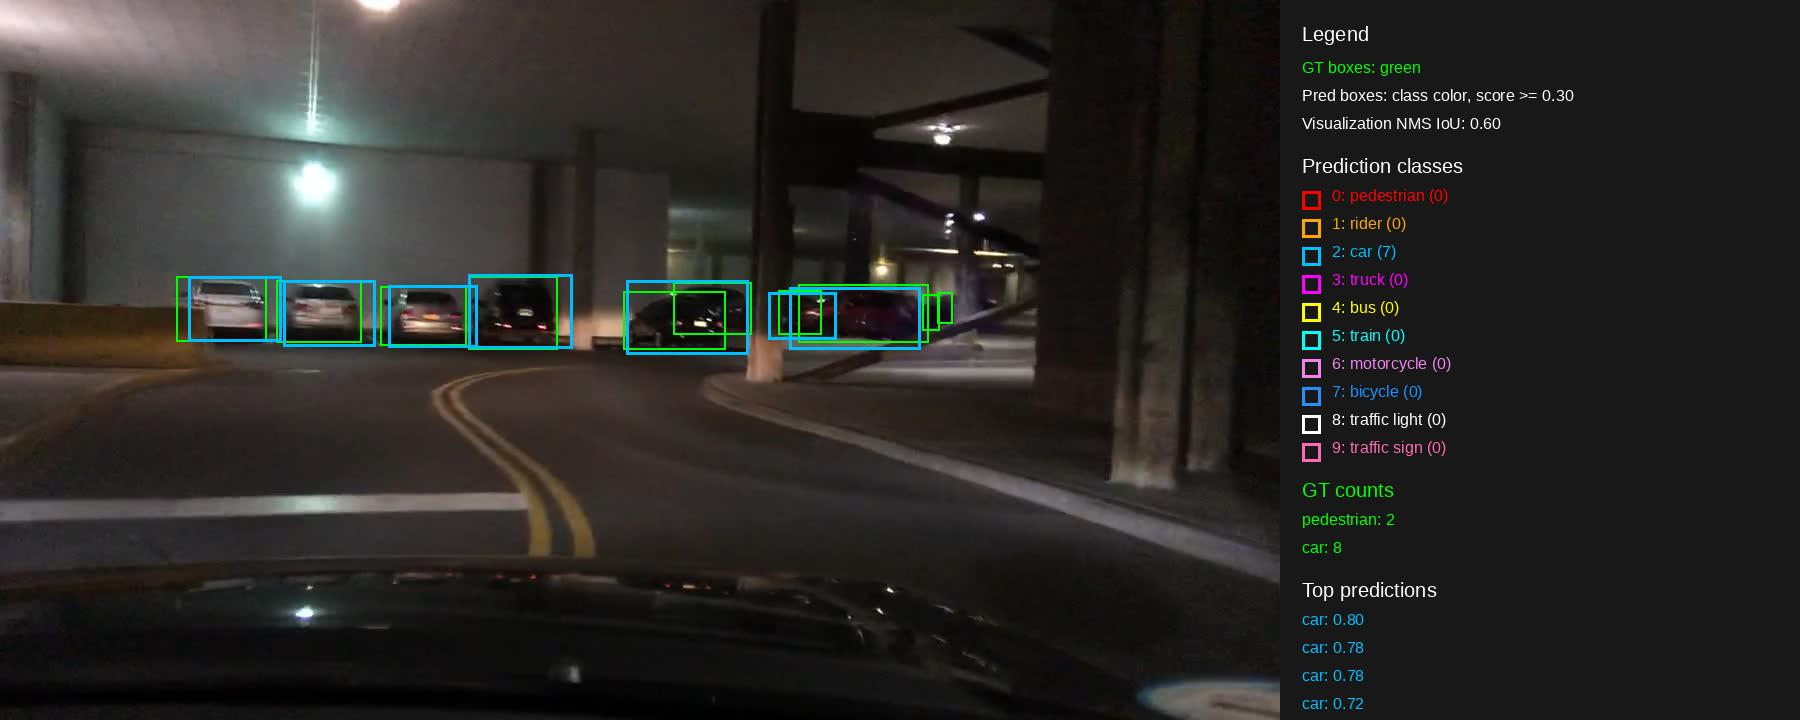

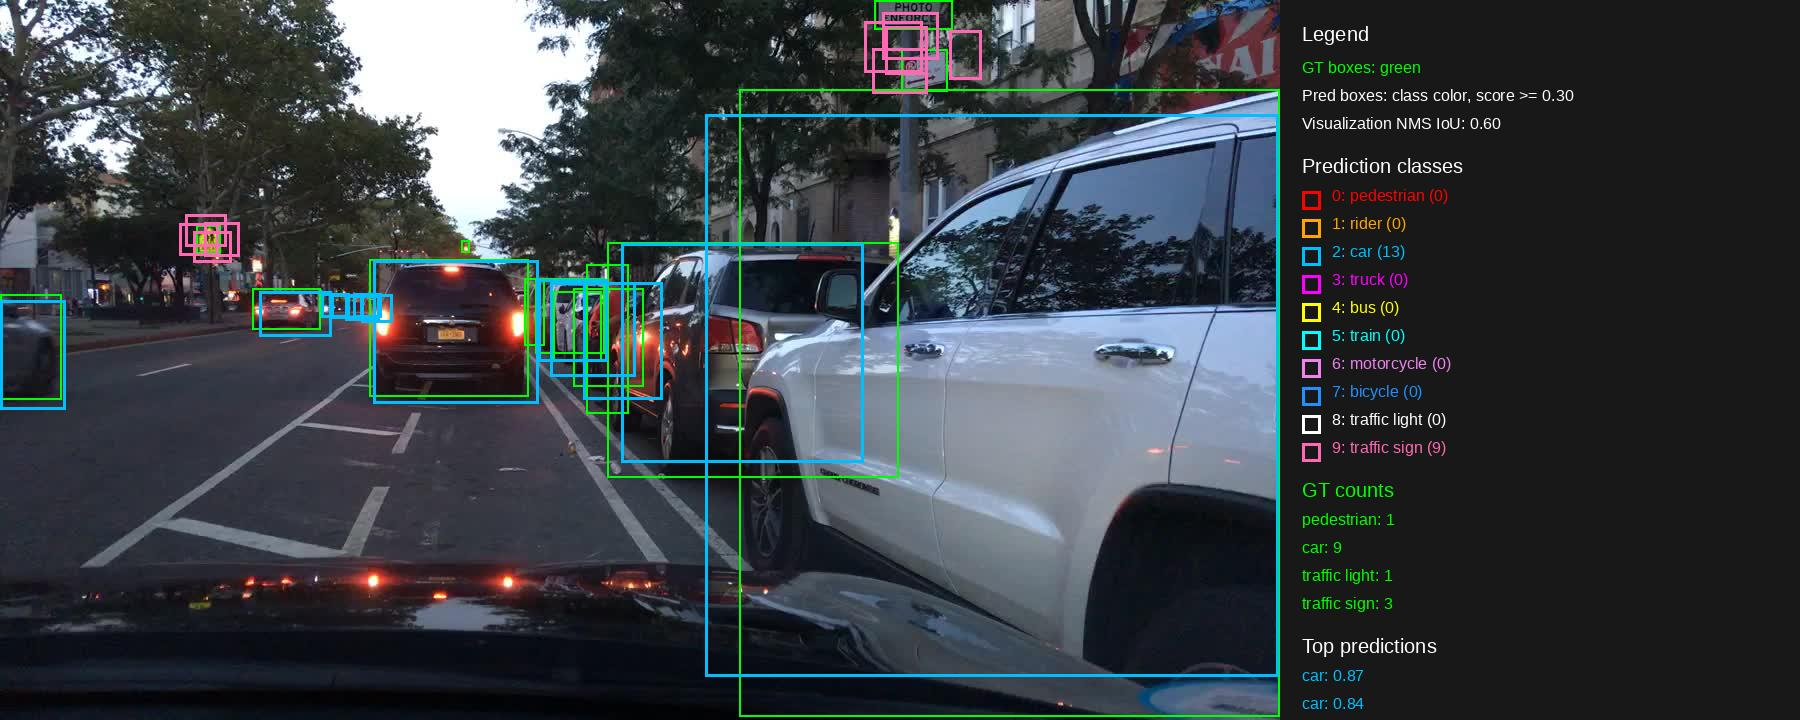

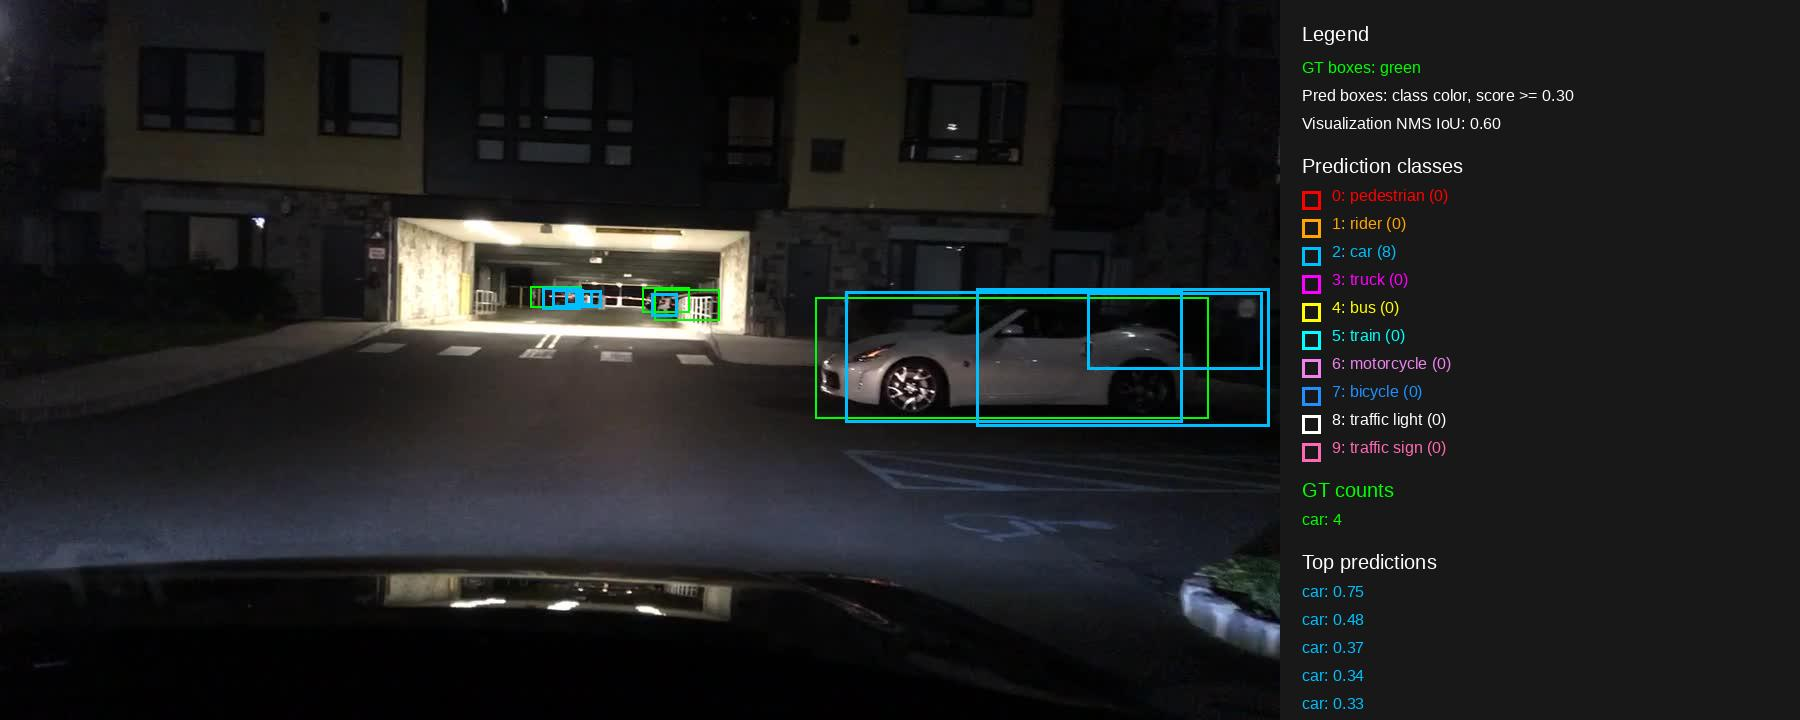

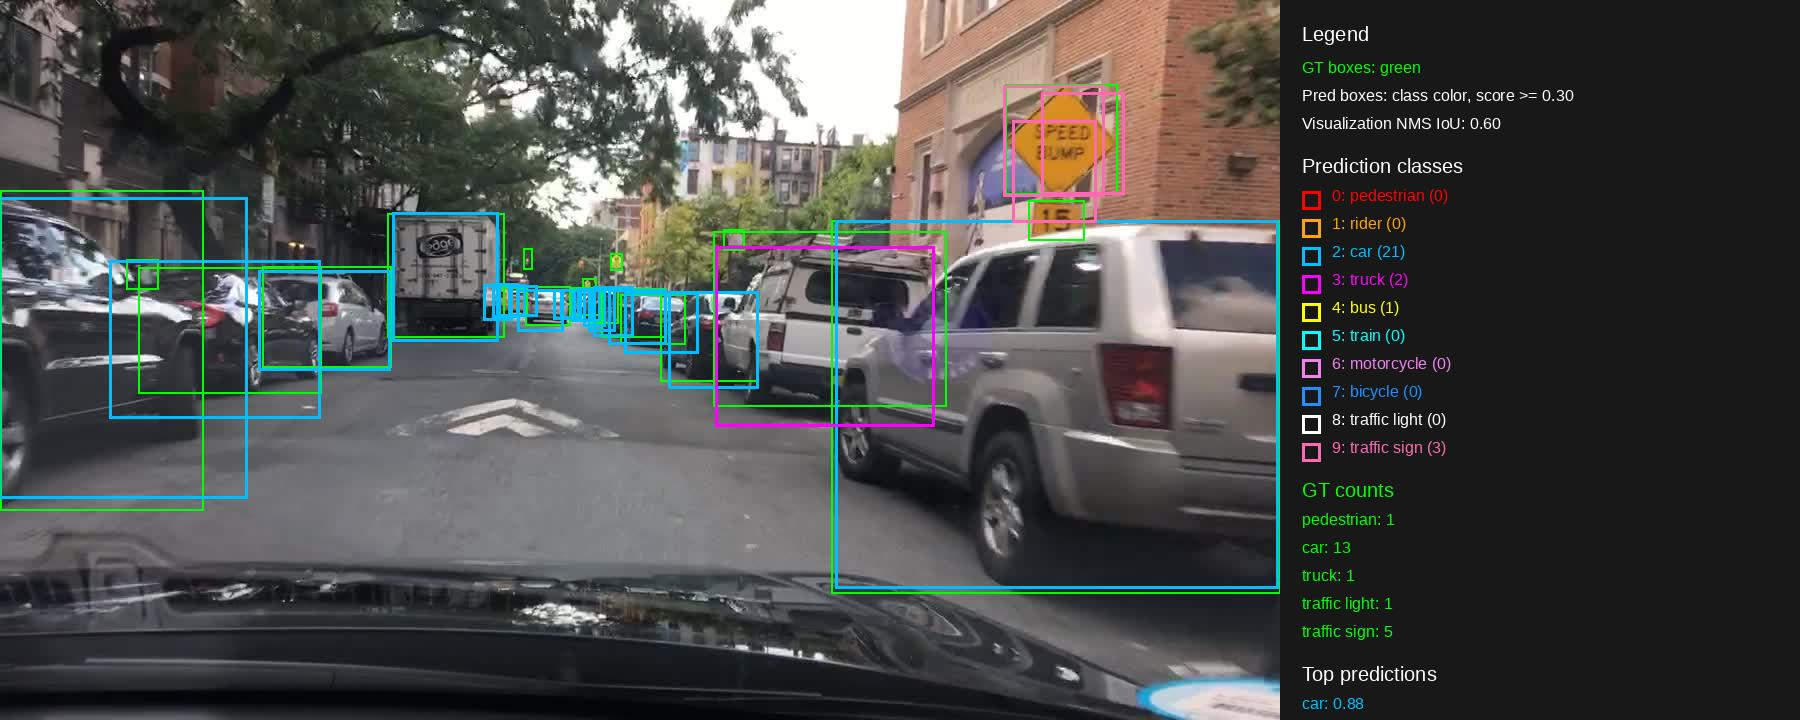

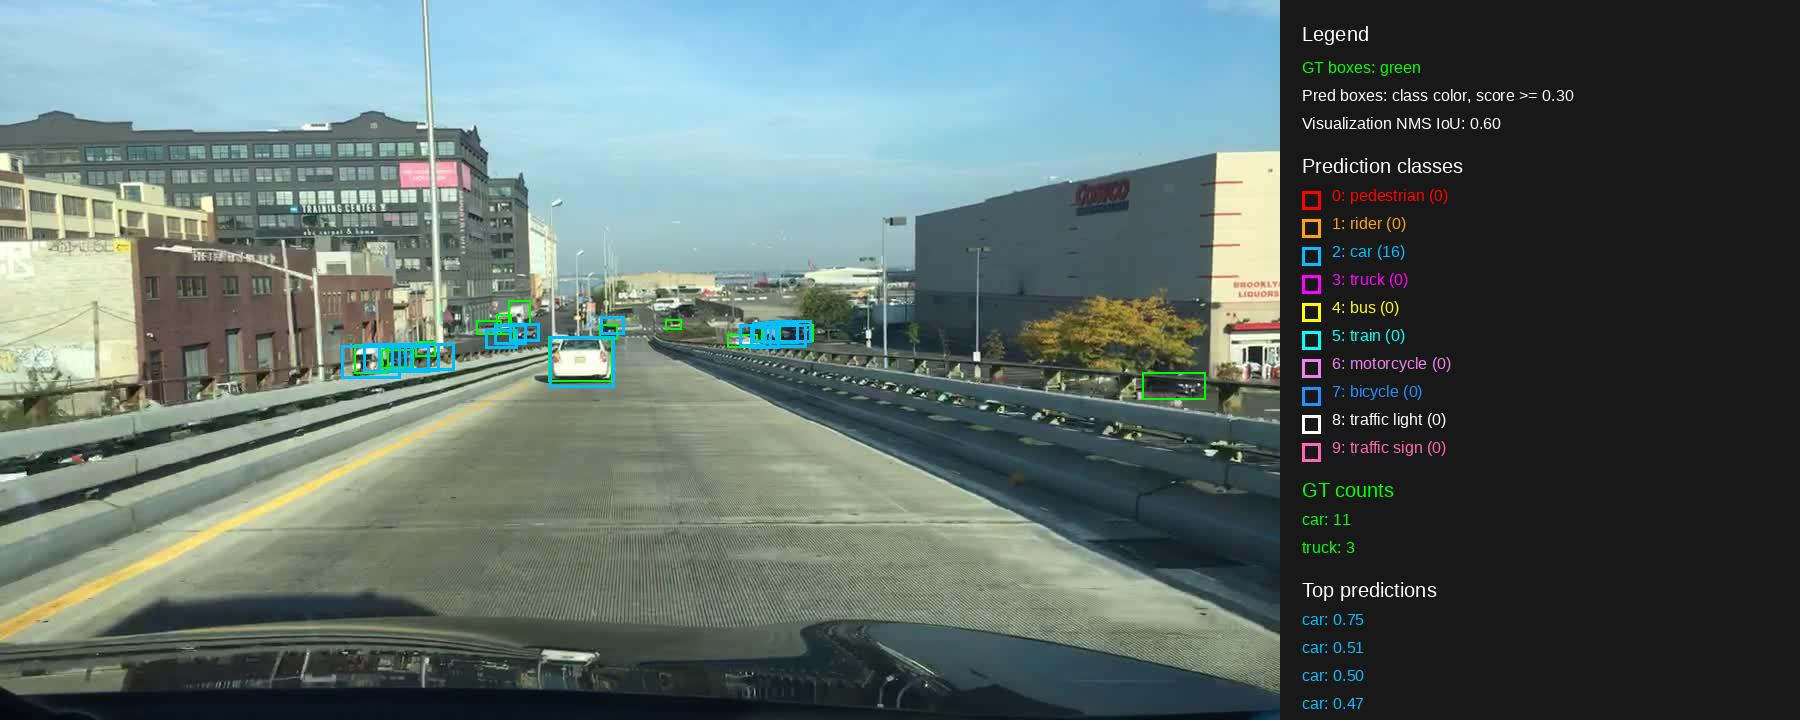

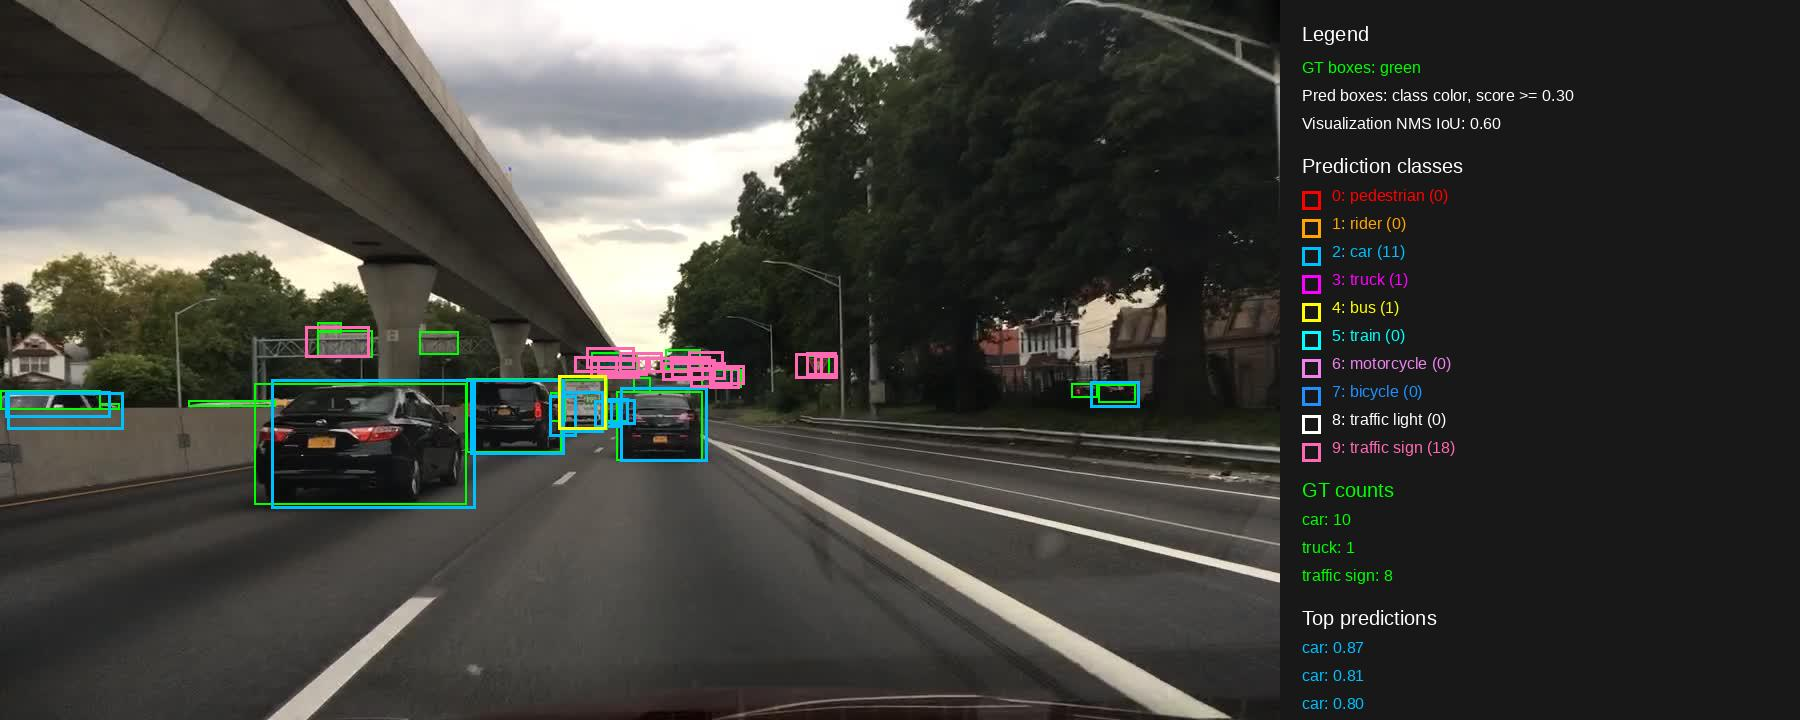

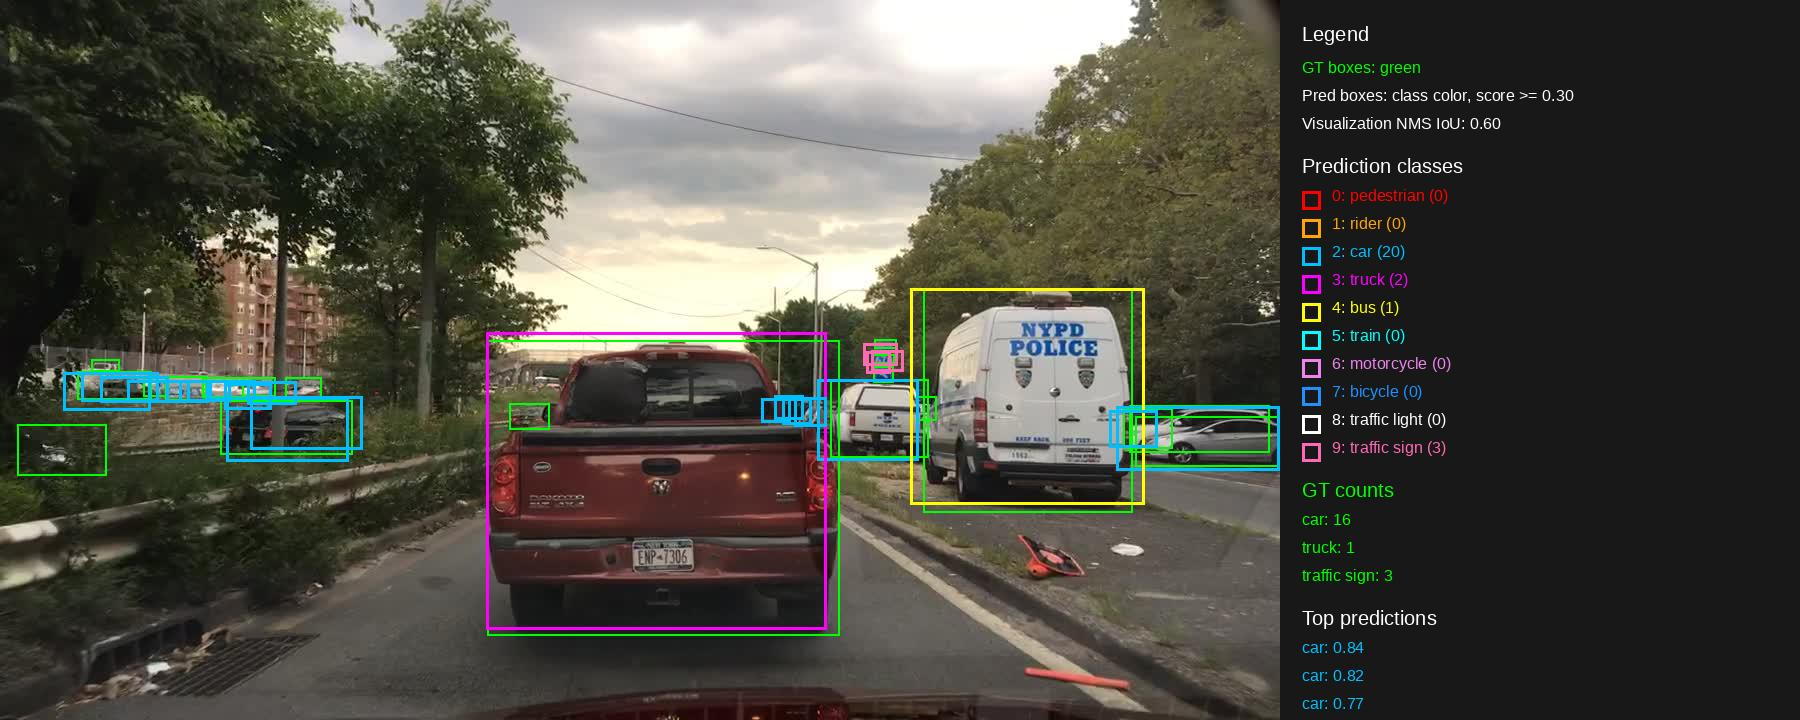

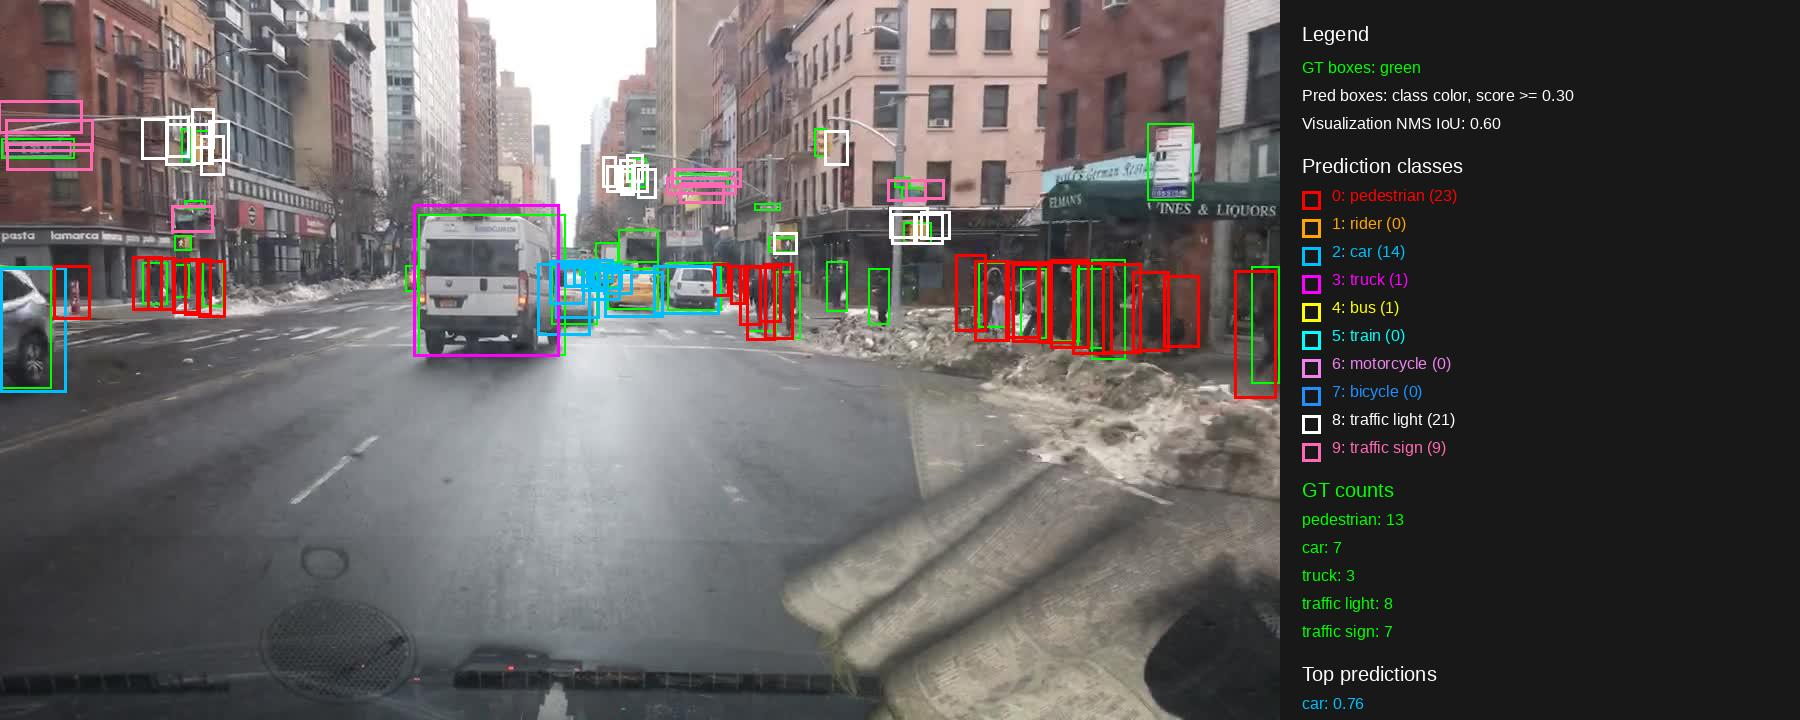

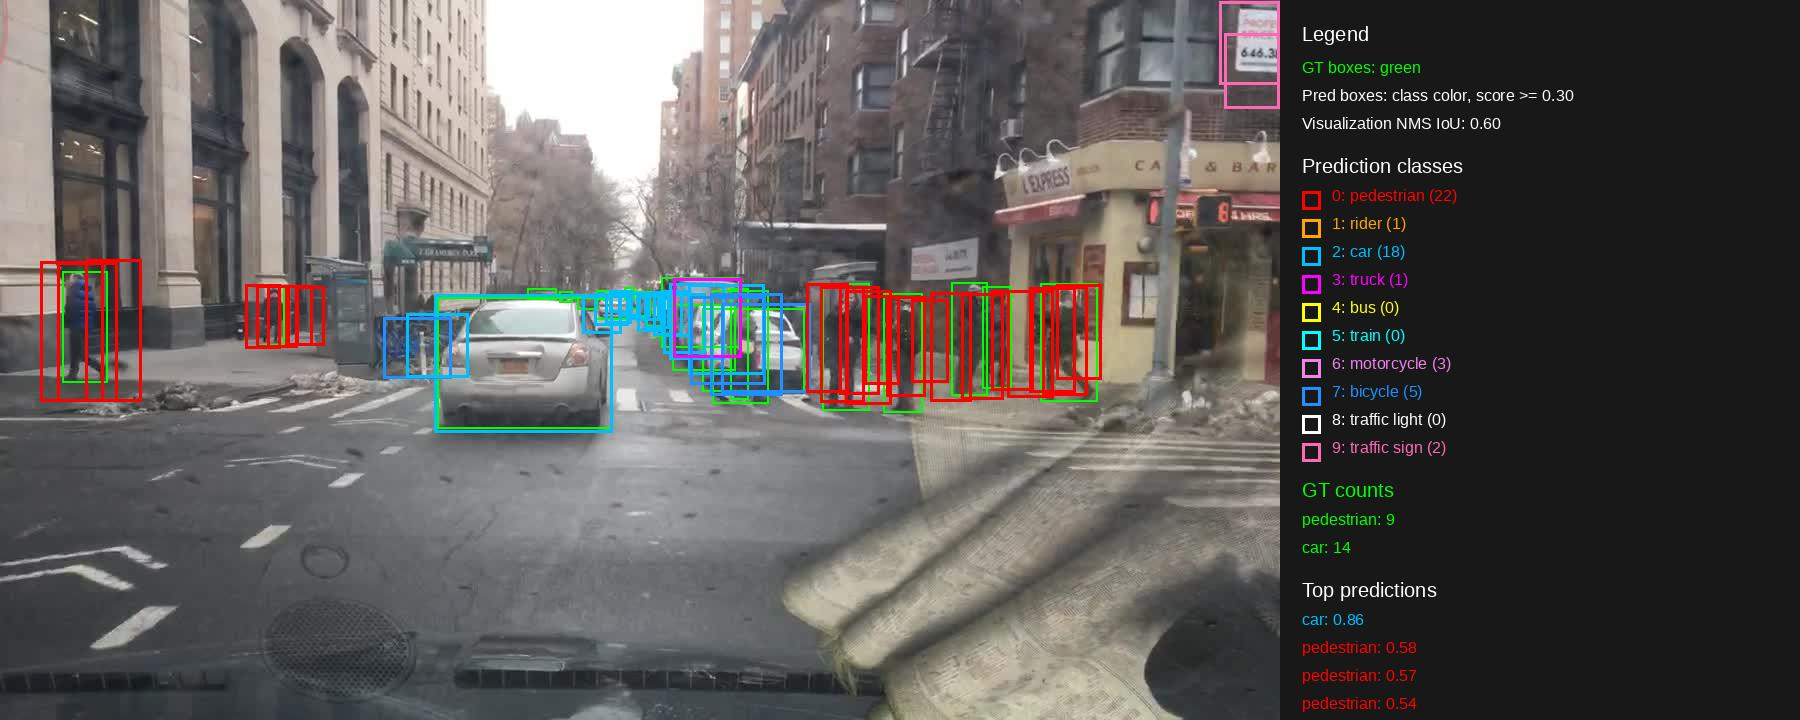

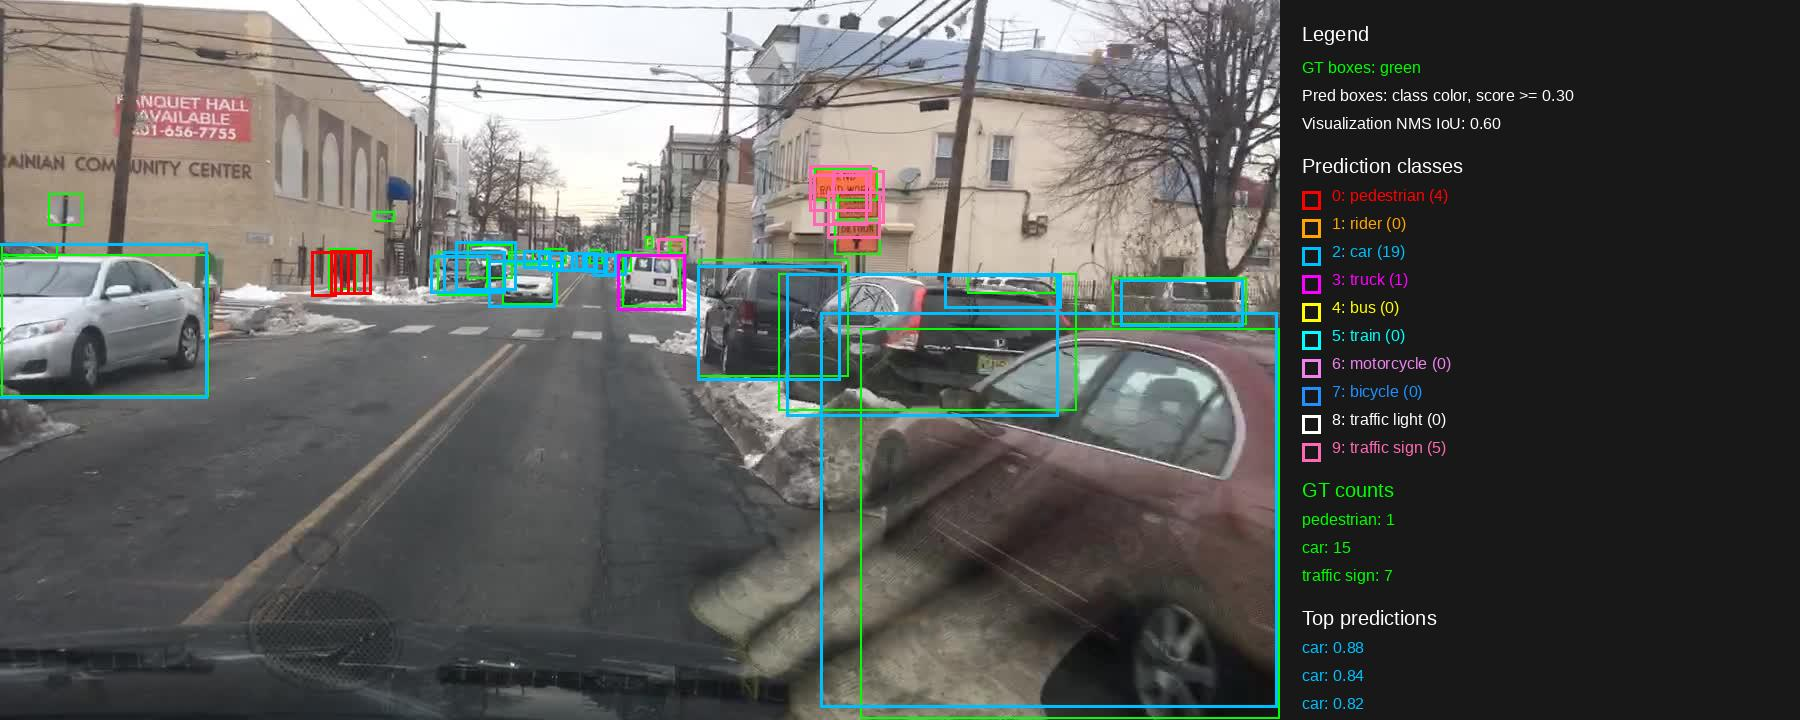

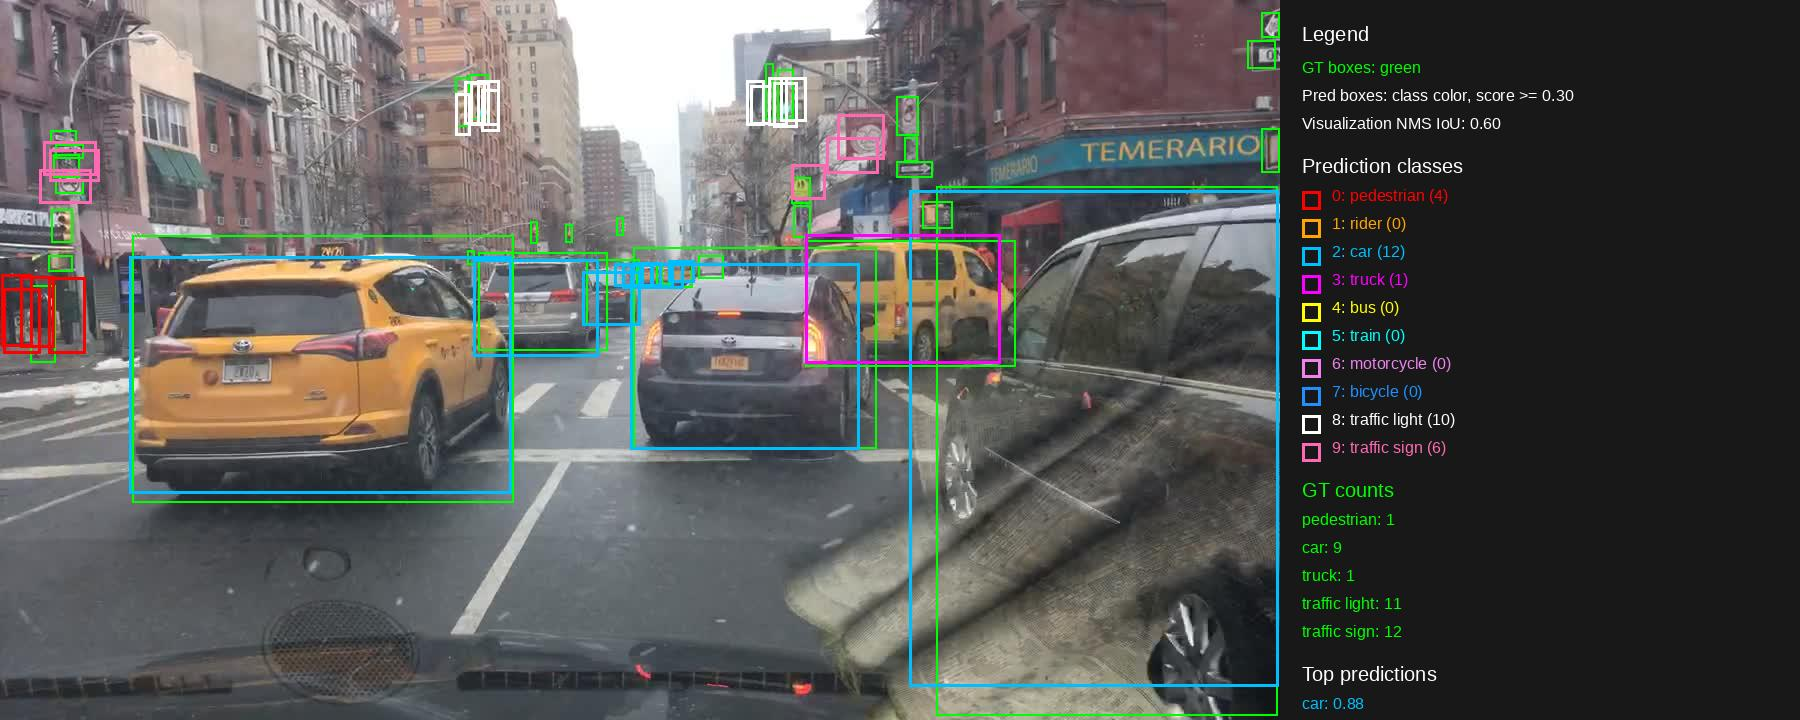

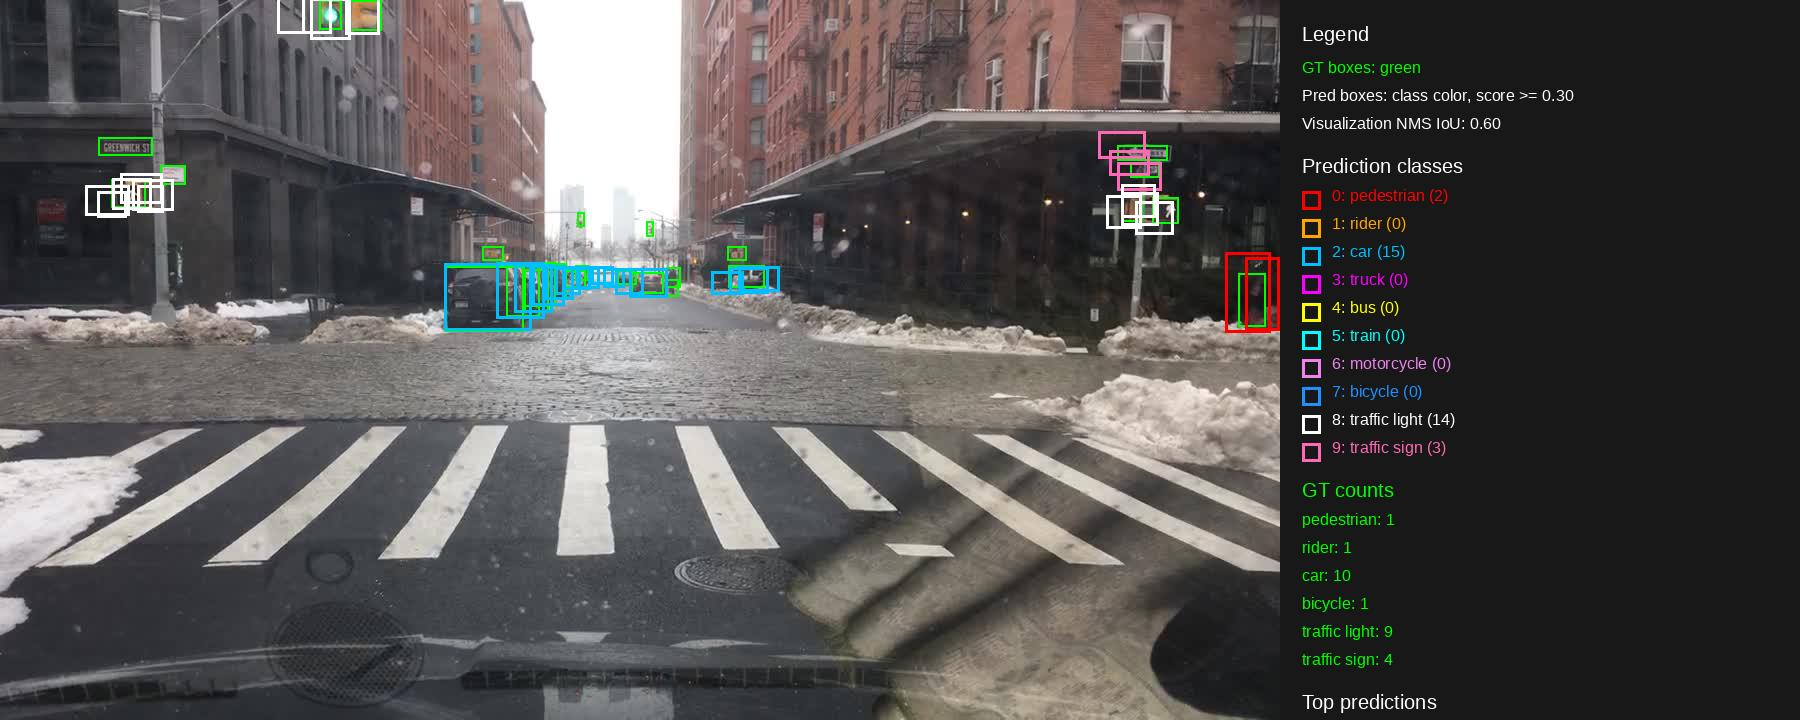

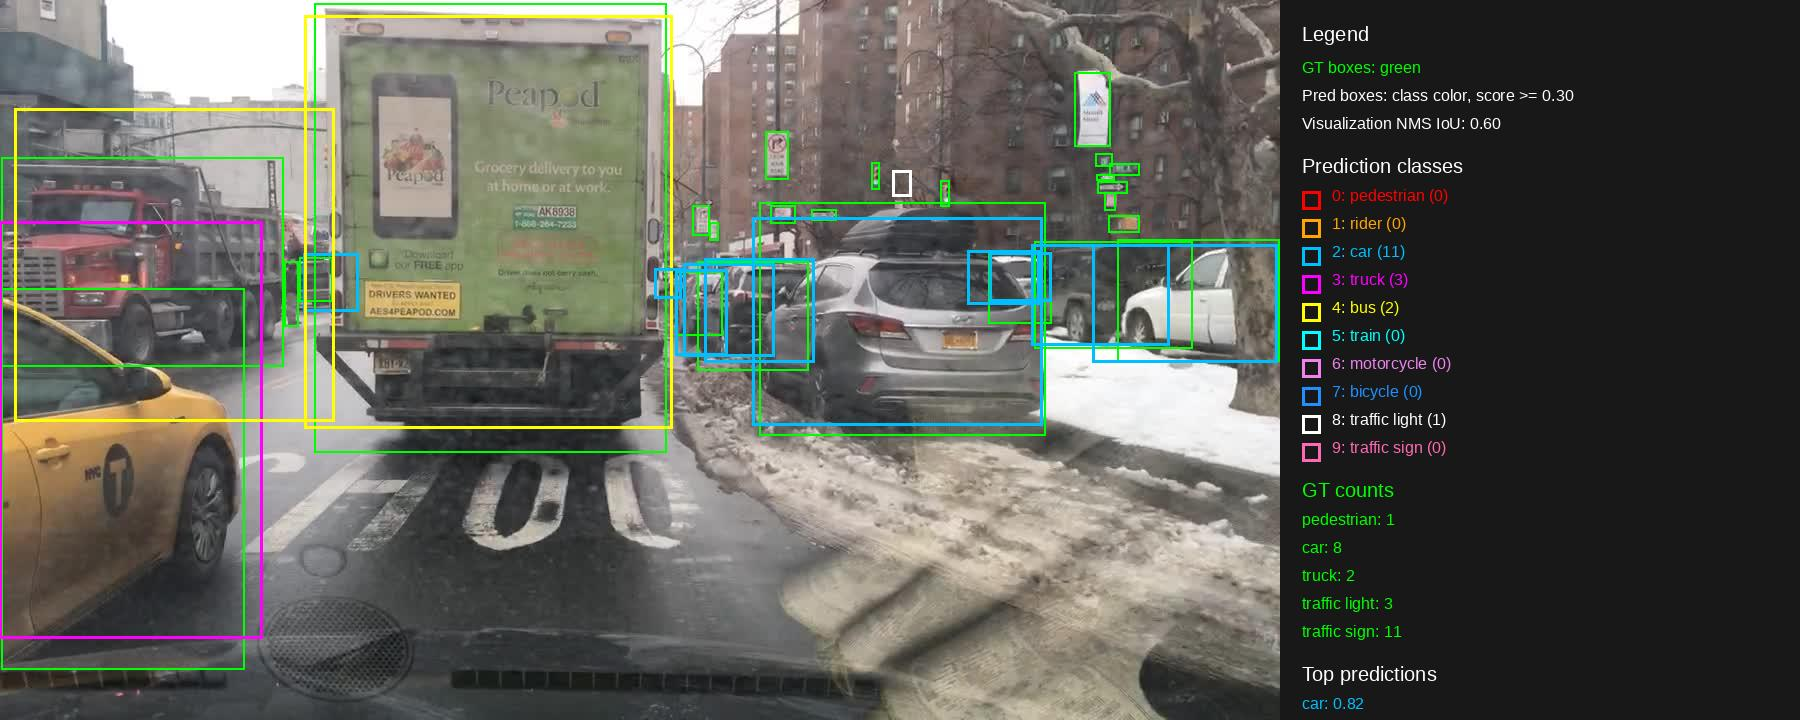

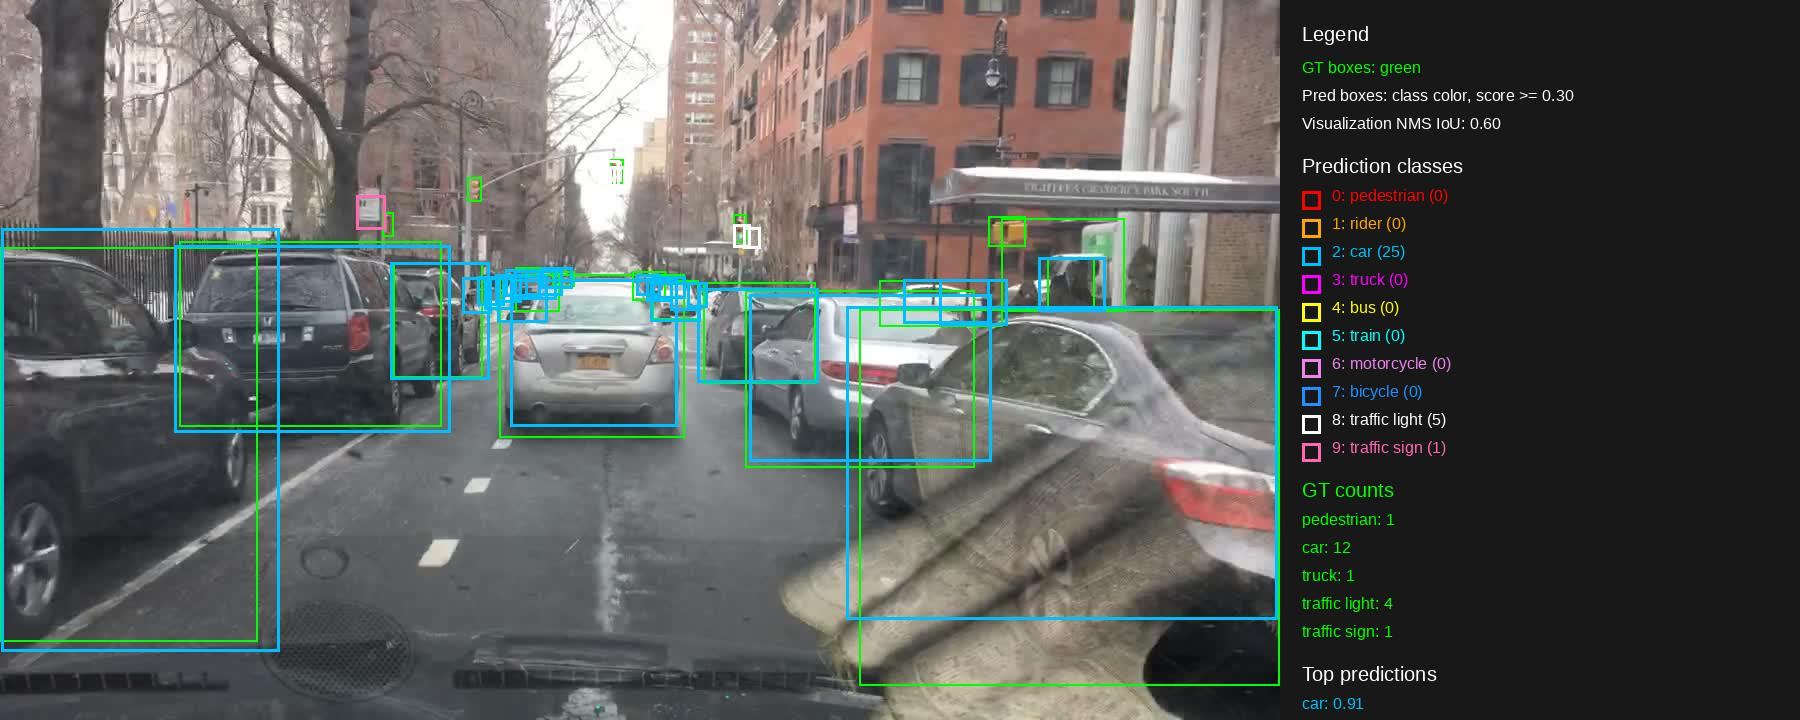

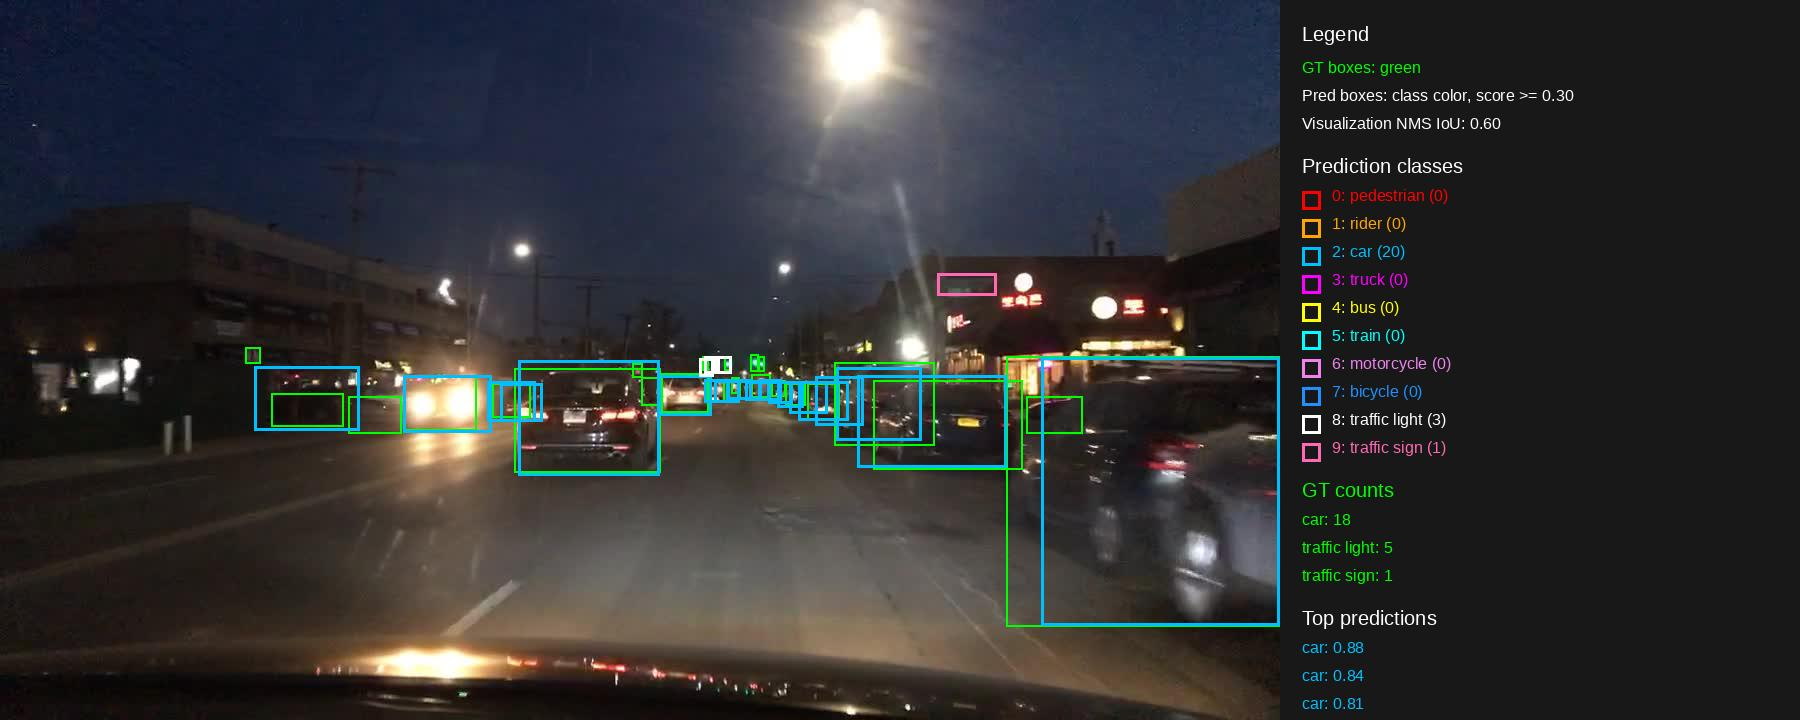

In [7]:
VIS_DIR = Path("/content/drive/MyDrive/projects/ane-drive-perc/runs/ane/ane_s_bdd30k_544x960_a100_bs32_e65/debug/predictions")

images = sorted(VIS_DIR.glob("*.jpg")) + sorted(VIS_DIR.glob("*.png"))

print(f"{len(images)} images at {VIS_DIR}")

for path in images[:24]:
    display(Image(filename=str(path), width=900))

generic visualizations

In [ ]:
CHECKPOINT = (
    "/content/drive/MyDrive/projects/ane-drive-perc/runs/ane/"
    "ane_s_bdd30k_544x960_a100_bs32_e65/checkpoints/best.pt"
)
EXPERIMENT = "ane_s_bdd_finetune"
RUN_NAME = "visualize_anycheckpoint"
COCO_ROOT = "/content/adp/data/exports/bdd_det10_train30k_s42/coco"

os.environ.update(
    {
        "VIS_CHECKPOINT": CHECKPOINT,
        "VIS_EXPERIMENT": EXPERIMENT,
        "VIS_RUN_NAME": RUN_NAME,
        "VIS_COCO_ROOT": COCO_ROOT,
    }
)

print(f"configured viz for: {CHECKPOINT}")

In [ ]:
%cd /content/adp

!uv run python -u -m adp.eval.visualize_predictions \
  +experiment=${VIS_EXPERIMENT} \
  experiment.name=${VIS_RUN_NAME} \
  paths.runs=/content/drive/MyDrive/projects/ane-drive-perc/runs/visualize \
  train.coco_root=${VIS_COCO_ROOT} \
  eval.checkpoint_path=${VIS_CHECKPOINT} \
  eval.score_threshold=0.3 \
  eval.max_images=24 \
  eval.nms_iou_threshold=0.6 \
  train.device=cuda

In [ ]:
vis_dir = Path(
    f"/content/drive/MyDrive/projects/ane-drive-perc/runs/visualize/"
    f"{os.environ['VIS_RUN_NAME']}/reports/visualizations"
)

images = sorted(vis_dir.glob("*.jpg")) + sorted(vis_dir.glob("*.png"))

print(f"{len(images)} images at {vis_dir}")

for path in images:
    display(Image(filename=str(path), width=900))